In [2]:
import numpy as np
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

rho=0.3: cosine=0.762


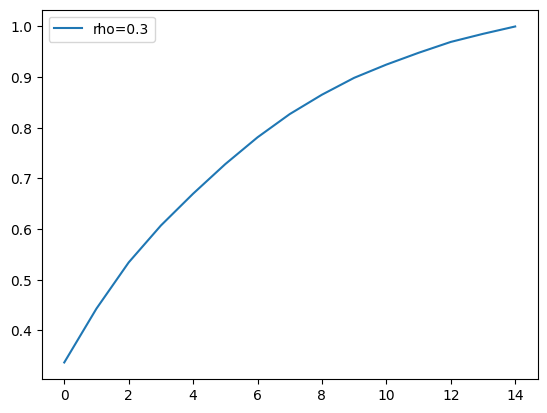

In [3]:
rng = np.random.default_rng(0)
n, p = 40, 15
M0 = rng.standard_normal((n, p))         

rho = .3
C = (1 - rho) * np.eye(n) + rho * np.ones((n, n))   # n×n -> correlate ROWS
L = np.linalg.cholesky(C)
M = L @ M0                                          # left-multiply; 20×15

#M = M - M.mean(axis=1, keepdims=True)
_, S, Vt = np.linalg.svd(M, full_matrices=False)     # no centering
var_expl = np.cumsum(S**2 / (S**2).sum())
d = pdist(M, metric='cosine')                       # cosine on raw M

print(f'rho={rho}: cosine={d.mean():.3f}')
plt.plot(var_expl, label=f'rho={rho}')

plt.legend()
plt.show()

In [4]:
for k in [2, 5, 8, 10, 12, 15]:
    Pk = M @ Vt[:k].T
    cos = pdist(Pk, metric="cosine")
    eucl = pdist(Pk, metric="euclidean")
    print(f'{k:2d} comps -> cos={cos.mean():.3f}, eucl={eucl.mean()}')

 2 comps -> cos=0.362, eucl=2.027055970104817
 5 comps -> cos=0.610, eucl=3.2492551582345115
 8 comps -> cos=0.708, eucl=3.9145302165586084
10 comps -> cos=0.731, eucl=4.170631660119783
12 comps -> cos=0.747, eucl=4.343940835710335
15 comps -> cos=0.762, eucl=4.518146311772714


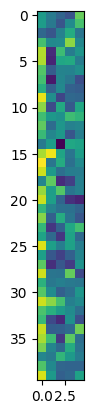

In [10]:
k = 5
Pk = M @ Vt[:k].T
plt.imshow(Pk)

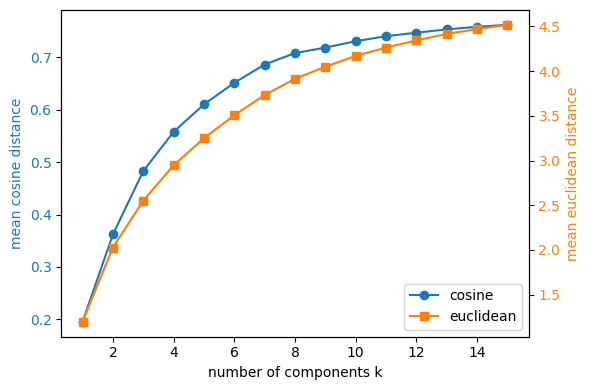

In [6]:
ks = np.arange(1, M.shape[1] + 1)
cos_k = np.empty(len(ks))
eucl_k = np.empty(len(ks))
for i, k in enumerate(ks):
    Pk = M @ Vt[:k].T
    cos_k[i] = pdist(Pk, metric="cosine").mean()
    eucl_k[i] = pdist(Pk, metric="euclidean").mean()

fig, ax1 = plt.subplots(figsize=(6, 4))
ax2 = ax1.twinx()
l1, = ax1.plot(ks, cos_k, 'o-', color="C0", label="cosine")
l2, = ax2.plot(ks, eucl_k, 's-', color="C1", label="euclidean")

ax1.set_xlabel("number of components k")
ax1.set_ylabel("mean cosine distance", color="C0")
ax2.set_ylabel("mean euclidean distance", color="C1")
ax1.tick_params(axis="y", labelcolor="C0")
ax2.tick_params(axis="y", labelcolor="C1")
ax1.legend(handles=[l1, l2], loc="lower right")
fig.tight_layout()
plt.show()

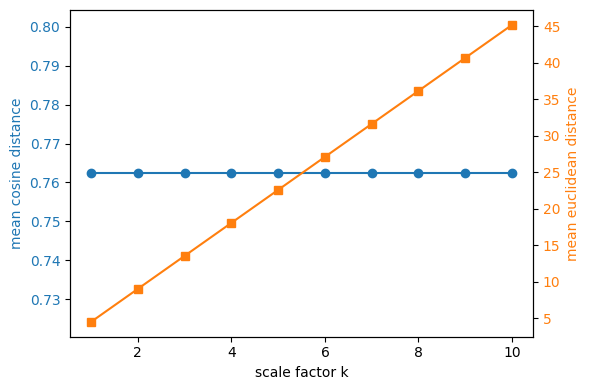

In [8]:
ks = np.arange(1, 11)
cos_k = np.empty(len(ks))
eucl_k = np.empty(len(ks))
for i, k in enumerate(ks):
    M_scale = M * k
    cos_k[i] = pdist(M_scale, metric="cosine").mean()
    eucl_k[i] = pdist(M_scale, metric="euclidean").mean()

fig, ax1 = plt.subplots(figsize=(6, 4))
ax2 = ax1.twinx()
l1, = ax1.plot(ks, cos_k, 'o-', color="C0", label="cosine")
l2, = ax2.plot(ks, eucl_k, 's-', color="C1", label="euclidean")

ax1.set_xlabel("scale factor k")
ax1.set_ylabel("mean cosine distance", color="C0")
ax2.set_ylabel("mean euclidean distance", color="C1")
ax1.tick_params(axis="y", labelcolor="C0")
ax2.tick_params(axis="y", labelcolor="C1")
#ax1.legend(handles=[l1, l2], loc="center right")
fig.tight_layout()
plt.show()

In [5]:
for k in [1, 2, 3, 5, 10]:
    M_scale = M * k
    cos = pdist(M_scale, metric="cosine")
    eucl = pdist(M_scale, metric="euclidean")
    print(f'{k:2d}x scale -> cos={cos.mean():.3f}, eucl={eucl.mean()}')

 1x scale -> cos=0.762, eucl=4.518146311772712
 2x scale -> cos=0.762, eucl=9.036292623545425
 3x scale -> cos=0.762, eucl=13.554438935318139
 5x scale -> cos=0.762, eucl=22.59073155886356
10x scale -> cos=0.762, eucl=45.18146311772712


In [14]:
for k in [1, 2, 3, 5, 10]:
    M_scale = M.copy()
    M_scale[:10] *= k
    cos = pdist(M_scale, metric="cosine")
    eucl = pdist(M_scale, metric="euclidean")
    print(f'{k:2d}x scale -> cos={cos.mean():.3f}, eucl={eucl.mean()}')

 1x scale -> cos=0.803, eucl=4.642840876414829
 2x scale -> cos=0.803, eucl=7.128507158064887
 3x scale -> cos=0.803, eucl=9.882730357874541
 5x scale -> cos=0.803, eucl=15.591888837672482
10x scale -> cos=0.803, eucl=30.109493122144983
